# Analyse Feldman Cousins for $\gamma$
## Check what the $\gamma$ uncertainty is for both solutions

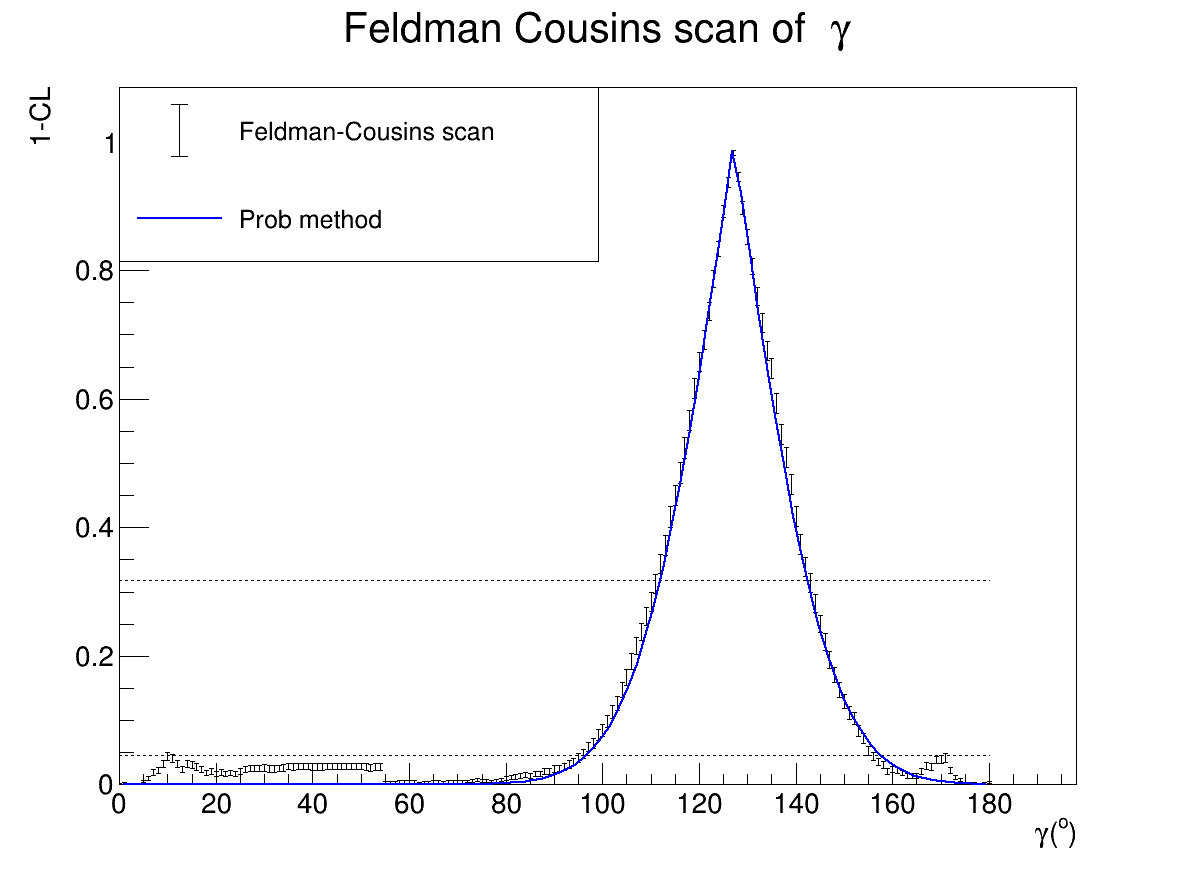

In [1]:
std::vector<double> x, y, y_err;
for(std::size_t gamma = 0; gamma <= 180; gamma++) {
    std::string Filename = "/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/";
    Filename += "FeldmanCousinsGammaFitResults/Gamma_" + std::to_string(gamma) + ".txt";
    std::ifstream File(Filename);
    double CL_value;
    File >> CL_value;
    x.push_back(gamma);
    y.push_back(CL_value);
    File >> CL_value;
    y_err.push_back(CL_value);
}
TGraphErrors Graph(x.size(), x.data(), y.data(), nullptr, y_err.data());
Graph.SetTitle("Feldman Cousins scan of #gamma;#gamma(^{o});1-CL");
TCanvas c("c", "", 1200, 900);
Graph.Draw("APE");
TLine Sigma1(0.0, TMath::Prob(1.0, 1), 180.0, TMath::Prob(1.0, 1));
Sigma1.SetLineStyle(kDashed);
Sigma1.Draw("SAME");
TLine Sigma2(0.0, TMath::Prob(4.0, 1), 180.0, TMath::Prob(4.0, 1));
Sigma2.SetLineStyle(kDashed);
Sigma2.Draw("SAME");
TF1 GaussianCL("GaussianCL","TMath::Prob(TMath::Power((127.163 - x)/15.225, 2), 1)", 0.0, 180.0);
GaussianCL.SetLineColor(kBlue);
GaussianCL.Draw("SAME");
TLegend Legend(0.1, 0.7, 0.5, 0.9);
Legend.AddEntry(&Graph, "Feldman-Cousins scan", "PE");
Legend.AddEntry(&GaussianCL, "Prob method", "L");
Legend.Draw();
c.Draw();